In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [ ]:
# OTT Streaming Platform Analytics Engine
### Built by: Jahanvi Rana

# **Project Overview:** This notebook processes an end-to-end analytical assessment of 
# raw user engagement, subscription revenues, and content performance metrics on an OTT streaming platform.

In [ ]:
# 1. System Environment Configuration & Data Loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.style.use('seaborn-v0_8-muted')

# CRITICAL FIX: Make sure to load your dataframe before checking its shape!
df = pd.read_csv('/kaggle/input/datasets/ranajahanvi/ott-streaming-platform-analysis/streaming_service_data.csv')

: 

In [ ]:
## 2. Data Integrity & Quality Assessment
# We evaluate the operational constraints of our dataframe by checking 
# feature space, data type casting accuracy, missing entries, and redundant observations.

In [3]:
print("-" * 30)
print("📊 Dataset Overview")
print("-" * 30)
print(f"✅ Total Observations (Rows): {df.shape[0]}")
print(f"✅ Total Features (Columns): {df.shape[1]}")

print("\n" + "-" * 30)
print("🔍 Data Type Information")
print("-" * 30)
for dtype, count in df.dtypes.value_counts().items():
    print(f"• {dtype}: {count} columns")

print("\n" + "-" * 30)
print("🛠️ Data Cleaning")
print("-" * 30)
null_count = df.isnull().sum().sum()
if null_count == 0:
    print("✅ Missing Values: None. The dataset is complete.")
else:
    print(f"⚠️ Missing Values: {null_count} total nulls found.")

dup_count = df.duplicated().sum()
if dup_count == 0:
    print("✅ Duplicate Records: None. Every user entry is unique.")
else:
    print(f"⚠️ Duplicates: {dup_count} redundant rows detected.")

------------------------------
📊 Dataset Overview
------------------------------
✅ Total Observations (Rows): 1000
✅ Total Features (Columns): 23

------------------------------
🔍 Data Type Information
------------------------------
• object: 13 columns
• int64: 8 columns
• float64: 2 columns

------------------------------
🛠️ Data Cleaning
------------------------------
✅ Missing Values: None. The dataset is complete.
✅ Duplicate Records: None. Every user entry is unique.


In [ ]:
## 3. High-Level Descriptive Summary
# Identifying global metric thresholds, category variations
# and outlier boundaries across numerical and categorical features.

In [4]:
print("--- Numerical Feature Overview ---")
print(df.describe())

print("\n--- Categorical Feature Overview ---")
print(df.describe(include='object'))

--- Numerical Feature Overview ---
          User_ID  Monthly_Price  Watch_Hours  Active_Devices  Profile_Count  \
count  1000.00000    1000.000000  1000.000000      1000.00000    1000.000000   
mean   5610.52100      12.026000   254.516000         3.04600       3.460000   
std    2566.98922       3.238702   140.667264         1.42966       1.749703   
min    1003.00000       7.990000    10.000000         1.00000       1.000000   
25%    3587.75000       7.990000   136.000000         2.00000       2.000000   
50%    5694.00000      11.990000   256.000000         3.00000       3.000000   
75%    7794.25000      15.990000   373.250000         4.00000       5.000000   
max    9996.00000      15.990000   500.000000         5.00000       6.000000   

       Total_Movies_Watched  Total_Series_Watched  Recommended_Content_Count  \
count           1000.000000           1000.000000                1000.000000   
mean             515.897000             99.746000                  51.482000   
std 

In [ ]:
## 4. Operational Business Insights & Genre Leadership
# Analyzing distribution percentages for platform tiers, primary consumer taste points
# and pricing models, and time-on-platform correlations.

In [9]:
import pandas as pd

# --- [Keep your existing Top 5 and Membership blocks as they are] ---
print("-" * 40)
print(" ✅ Top 5 Most Popular Genres (By User Preference)")
print("-" * 40)
top_genres = df['Favorite_Genre'].value_counts().head(5)
for genre, count in top_genres.items():
    print(f"🔹 {genre:<15} | {count:>4} Users")

print("\n" + "-" * 40)
print("✅ Membership Status (% of Total User Base)")
print("-" * 40)
membership_pct = df['Membership_Status'].value_counts(normalize=True) * 100
for status, percentage in membership_pct.items():
    print(f"🔸 {status:<15} | {percentage:>6.2f}%")


# --- FIX 1: AVERAGE WATCH HOURS BY GENRE (Clean Console Table) ---
print("\n📊 AVERAGE WATCH HOURS BY GENRE")
print("-" * 40)
genre_engagement = df.groupby('Favorite_Genre')['Watch_Hours'].mean().sort_values(ascending=False)
for genre, hours in genre_engagement.items():
    print(f"🎬 {genre:<15} : {hours:>6.1f} hrs / week")


# --- FIX 2: MEDIAN SUBSCRIPTION PRICE BY PAYMENT CHANNEL (Context-Aware) ---
print("\n💳 MEDIAN SUBSCRIPTION PRICE BY PAYMENT CHANNEL")
print("-" * 40)
payment_pricing = df.groupby('Payment_Method')['Monthly_Price'].median().sort_values(ascending=False)

# Check if all medians are identical to explain the flat pricing naturally
if payment_pricing.nunique() == 1:
    print(f"📢 Flat-rate pricing model detected: ${payment_pricing.iloc[0]:.2f} across all channels.")
    print("   Breakdown by method:")
    for method in payment_pricing.index:
        print(f"   • {method:<15} : ${payment_pricing[method]:.2f}")
else:
    for method, price in payment_pricing.items():
        print(f"• {method:<15} : ${price:>6.2f}")


# --- FIX 3: CORRELATION ANALYSIS (Dynamic Human Interpretation) ---
correlation = df['Watch_Hours'].corr(df['Average_Rating_Given'])
print("\n🔍 CORRELATION ANALYSIS")
print("-" * 40)
print(f"• Raw Pearson Coefficient: {correlation:.4f}")

# Dynamic narrative generation based on the correlation value
if abs(correlation) < 0.1:
    strength = "no meaningful linear relationship"
elif abs(correlation) < 0.3:
    strength = "a weak relationship"
else:
    strength = "a noticeable relationship"

direction = "positive" if correlation > 0 else "negative"

print(f"📝 Quick Take: There is virtually {strength} ({direction}) between how long")
print(f"   a user watches content and the ratings they provide. Higher engagement")
print(f"   does not necessarily guarantee a higher or lower score.")

----------------------------------------
 ✅ Top 5 Most Popular Genres (By User Preference)
----------------------------------------
🔹 Horror          |  157 Users
🔹 Action          |  150 Users
🔹 Comedy          |  146 Users
🔹 Romance         |  146 Users
🔹 Drama           |  142 Users

----------------------------------------
✅ Membership Status (% of Total User Base)
----------------------------------------
🔸 Active          |  26.30%
🔸 Expired         |  25.90%
🔸 Cancelled       |  24.50%
🔸 Paused          |  23.30%

📊 AVERAGE WATCH HOURS BY GENRE
----------------------------------------
🎬 Comedy          :  263.4 hrs / week
🎬 Documentary     :  260.1 hrs / week
🎬 Romance         :  258.2 hrs / week
🎬 Horror          :  256.3 hrs / week
🎬 Sci-Fi          :  251.4 hrs / week
🎬 Drama           :  249.6 hrs / week
🎬 Action          :  242.9 hrs / week

💳 MEDIAN SUBSCRIPTION PRICE BY PAYMENT CHANNEL
----------------------------------------
📢 Flat-rate pricing model detected: $11.99 acro

In [ ]:
## 5. Cohort Analysis & Acquisition Tracking
# Transforming timestamps into structural monthly variables to monitor registration velocity 
# and identify customer acquisition inflection points.

In [6]:
df['Join_Date'] = pd.to_datetime(df['Join_Date'], format='%d-%m-%Y')
df['Join_Month'] = df['Join_Date'].dt.to_period('M')

print("📈 USER ACQUISITION TREND (Monthly)")
growth_trend = df['Join_Month'].value_counts().sort_index().to_frame(name='New_Signups')
growth_trend.index.name = 'Month'
growth_trend['Growth_Rate_%'] = growth_trend['New_Signups'].pct_change() * 100
print(growth_trend.tail(12).to_string(formatters={'Growth_Rate_%': '{:.2f}%'.format}))

print(f"\n🚀 Peak Acquisition Month: {growth_trend['New_Signups'].idxmax()}")
print(f"📊 Average Monthly Sign-ups: {growth_trend['New_Signups'].mean():.1f}")

📈 USER ACQUISITION TREND (Monthly)
         New_Signups Growth_Rate_%
Month                             
2024-01           40       -27.27%
2024-02           50        25.00%
2024-03           33       -34.00%
2024-04           36         9.09%
2024-05           36         0.00%
2024-06           45        25.00%
2024-07           46         2.22%
2024-08           42        -8.70%
2024-09           40        -4.76%
2024-10           40         0.00%
2024-11           39        -2.50%
2024-12           24       -38.46%

🚀 Peak Acquisition Month: 2023-12
📊 Average Monthly Sign-ups: 40.0


In [ ]:
## 6. Strategic KPI Engine & Visual Storytelling
#Computing corporate KPIs and rendering presentation-ready distributions to support decision-making frameworks.

🚀 STRATEGIC KPI REPORT: STREAMING SERVICE HEALTH
📊 PLATFORM ENGAGEMENT
• Average Watch Hours per User : 254.52 hrs
• Content 'Stickiness' Rate     : 202.70%

💰 REVENUE PERFORMANCE
• Active       Revenue Contribution : $3,165.37
• Cancelled    Revenue Contribution : $3,001.55
• Expired      Revenue Contribution : $3,025.41
• Paused       Revenue Contribution : $2,833.67

📈 ACQUISITION MOMENTUM
• New Sign-ups (Current Month) : 24 users
• Month-over-Month Growth      : -38.46%


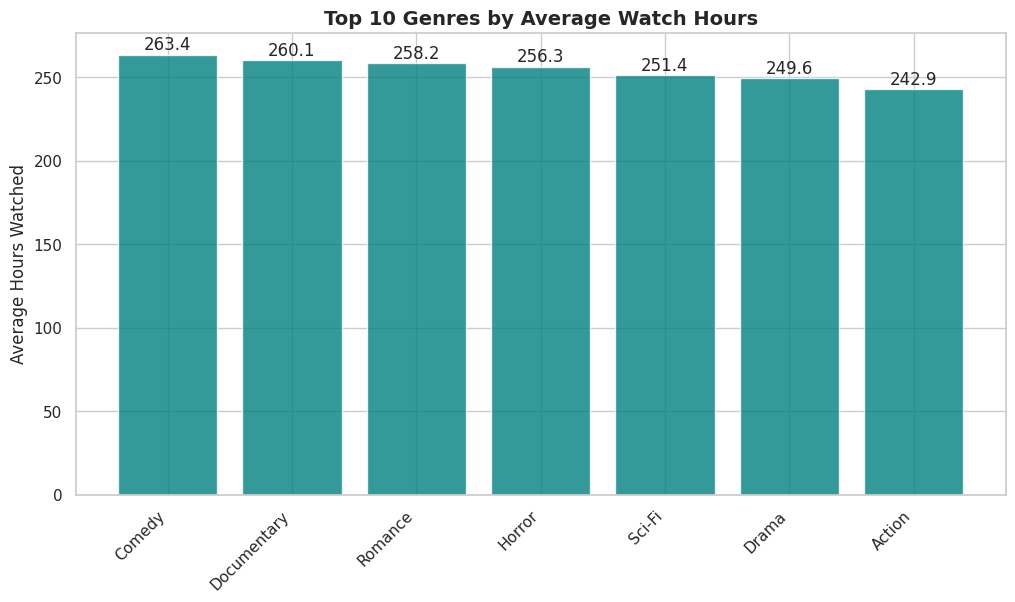

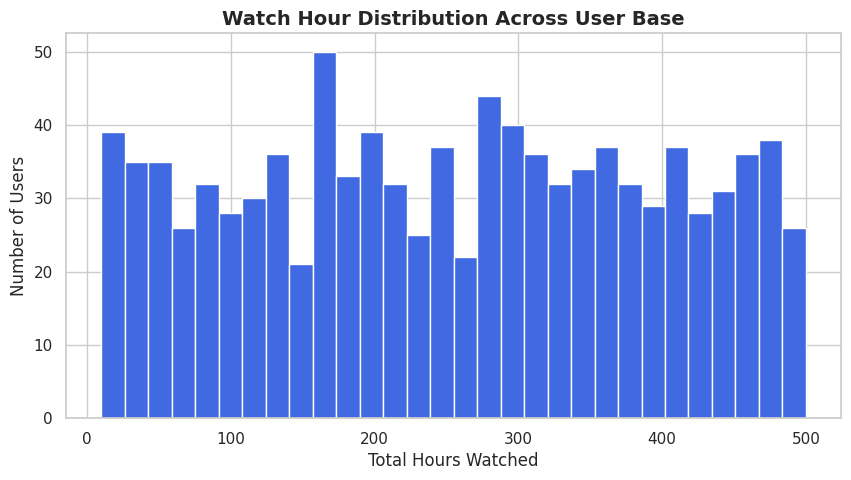

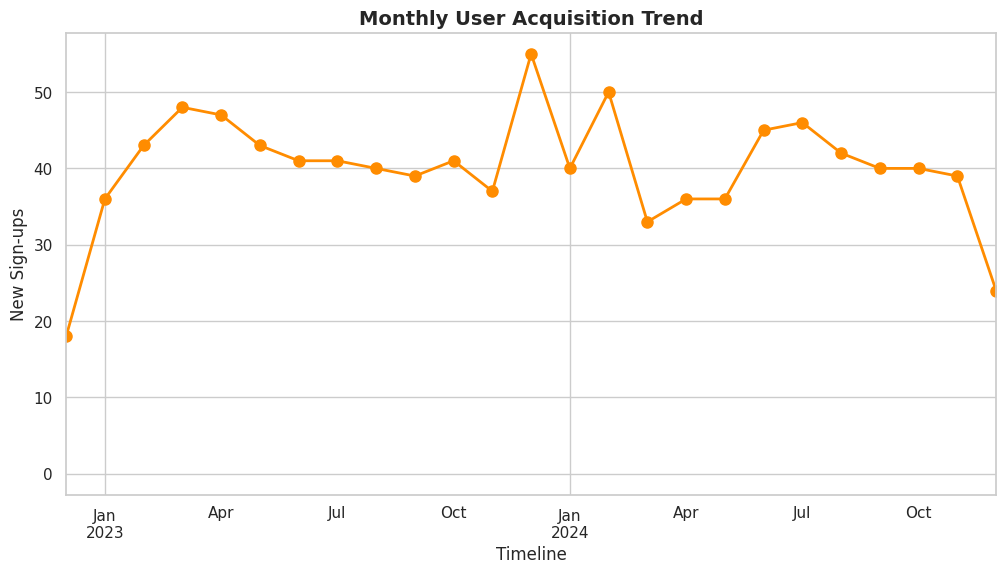

In [7]:
avg_watch_hours = df['Watch_Hours'].mean()
engagement_rate = (df['Total_Movies_Watched'].sum() / df['Watch_Hours'].sum()) * 100
revenue_by_membership = df.groupby('Membership_Status')['Monthly_Price'].sum()

print("=" * 45)
print("🚀 STRATEGIC KPI REPORT: STREAMING SERVICE HEALTH")
print("=" * 45)
print(f"📊 PLATFORM ENGAGEMENT")
print(f"• Average Watch Hours per User : {avg_watch_hours:.2f} hrs")
print(f"• Content 'Stickiness' Rate     : {engagement_rate:.2f}%")

print("\n💰 REVENUE PERFORMANCE")
for membership, revenue in revenue_by_membership.items():
    print(f"• {membership:12} Revenue Contribution : ${revenue:,.2f}")

print("\n📈 ACQUISITION MOMENTUM")
monthly_growth = df['Join_Month'].value_counts().sort_index()
recent_growth = monthly_growth.iloc[-1]
prev_growth = monthly_growth.iloc[-2]
growth_pct = ((recent_growth - prev_growth) / prev_growth) * 100
print(f"• New Sign-ups (Current Month) : {recent_growth} users")
print(f"• Month-over-Month Growth      : {growth_pct:+.2f}%")
print("=" * 45)

# --- VISUALIZATIONS ---
# Chart 1
plt.figure(figsize=(12, 6))
top_genres_plot = df.groupby('Favorite_Genre')['Watch_Hours'].mean().sort_values(ascending=False).head(10)
bars = plt.bar(top_genres_plot.index, top_genres_plot.values, color='teal', alpha=0.8)
plt.xticks(rotation=45, ha='right')
plt.title("Top 10 Genres by Average Watch Hours", fontsize=14, fontweight='bold')
plt.ylabel("Average Hours Watched")
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'{yval:.1f}', ha='center', va='bottom')
plt.show()

# Chart 2
plt.figure(figsize=(10, 5))
plt.hist(df['Watch_Hours'], bins=30, color='royalblue', edgecolor='white')
plt.title("Watch Hour Distribution Across User Base", fontsize=14, fontweight='bold')
plt.xlabel("Total Hours Watched")
plt.ylabel("Number of Users")
plt.show()

# Chart 3
plt.figure(figsize=(12, 6))
growth_data = df['Join_Month'].value_counts().sort_index()
growth_data.plot(kind='line', marker='o', color='darkorange', linewidth=2, markersize=8)
plt.fill_between(range(len(growth_data)), growth_data.values, color='orange', alpha=0.1)
plt.title("Monthly User Acquisition Trend", fontsize=14, fontweight='bold')
plt.xlabel("Timeline")
plt.ylabel("New Sign-ups")
plt.show()